In [ ]:
# Upload the exported dataset in Google Colab and restore `cleaned_dataset`
import json
from pathlib import Path

input_path = None

try:
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        input_path = Path(next(iter(uploaded.keys())))
    else:
        raise RuntimeError("No file was uploaded.")
except ImportError:
    fallback = Path("cleaned_dataset_backtranslation_export.jsonl")
    if fallback.exists():
        input_path = fallback
        print(f"Not running in Colab; using local file: {input_path.resolve()}")
    else:
        raise RuntimeError("Upload the JSONL file in Colab or place it in the notebook folder.")

cleaned_dataset = []
with input_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            cleaned_dataset.append(json.loads(line))

print(f"Loaded {len(cleaned_dataset)} documents into cleaned_dataset")


Saving cleaned_dataset_backtranslation_export.jsonl to cleaned_dataset_backtranslation_export.jsonl
Loaded 459 documents into cleaned_dataset


In [ ]:
# pip install -q transformers sentencepiece sacremoses langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 53.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 65.2 MB/s eta 0:00:00


In [ ]:
# Manual model loading
import re
import time
import random
import difflib
from langdetect import detect, DetectorFactory
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

DetectorFactory.seed = 13

device_id = 0 if torch.cuda.is_available() else -1
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    return model, tokenizer

def translate_text(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        generated_ids = model.generate(**inputs)
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Loading models manually to bypass pipeline task registry issues
model_en_es, tok_en_es = load_model_and_tokenizer("Helsinki-NLP/opus-mt-en-es")
model_es_en, tok_es_en = load_model_and_tokenizer("Helsinki-NLP/opus-mt-es-en")
model_en_de, tok_en_de = load_model_and_tokenizer("Helsinki-NLP/opus-mt-en-de")
model_de_en, tok_de_en = load_model_and_tokenizer("Helsinki-NLP/opus-mt-de-en")

# Creating simple wrappers to maintain compatibility with existing code calling en_es(text)
en_es = lambda x: translate_text(x, model_en_es, tok_en_es)
es_en = lambda x: translate_text(x, model_es_en, tok_es_en)
en_de = lambda x: translate_text(x, model_en_de, tok_en_de)
de_en = lambda x: translate_text(x, model_de_en, tok_de_en)

print("Translation models loaded successfully via manual initialization.")

Using device: cuda


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation models loaded successfully via manual initialization.


In [ ]:
import torch

# Increase batch size for faster GPU processing
TRANSLATION_BATCH_SIZE = 32


## Prevešću engleski na španski i nemački, a zatim nazad na engleski.


In [ ]:
def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def split_into_chunks(text: str, max_chars: int = 400):
    # Simple sentence-like split
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    chunks = []
    current = []
    current_len = 0

    for p in parts:
        if current_len + len(p) <= max_chars:
            current.append(p)
            current_len += len(p) + 1
        else:
            if current: chunks.append(" ".join(current))
            current = [p]
            current_len = len(p)
    if current: chunks.append(" ".join(current))
    return chunks

def batch_translate(texts, model, tokenizer, batch_size=TRANSLATION_BATCH_SIZE):
    # Optimized batch translation for manual models using global batch size
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_length=512)
        results.extend(tokenizer.batch_decode(generated_ids, skip_special_tokens=True))
    return results

def back_translate(text: str, pivot: str) -> str:
    chunks = split_into_chunks(text)
    if not chunks: return ""

    if pivot == "es":
        pivot_chunks = batch_translate(chunks, model_en_es, tok_en_es)
        back_chunks = batch_translate(pivot_chunks, model_es_en, tok_es_en)
    elif pivot == "de":
        pivot_chunks = batch_translate(chunks, model_en_de, tok_en_de)
        back_chunks = batch_translate(pivot_chunks, model_de_en, tok_de_en)

    return " ".join(back_chunks).strip()

def looks_like_english(text: str) -> bool:
    try: return detect(text) == "en"
    except: return False

def is_good_augmentation(original: str, candidate: str, min_words: int = 15, min_change: float = 0.02) -> bool:
    if not candidate or len(candidate.split()) < min_words:
        return False
    if not looks_like_english(candidate):
        return False
    o = normalize_text(original)
    c = normalize_text(candidate)
    sim = difflib.SequenceMatcher(None, o, c).ratio()
    return (1.0 - sim) >= min_change

In [ ]:
import os
import json
import tqdm

# 1. Filter the dataset to remove documents that are too large (The 'Megadocs')
MAX_DOC_CHARS = 50000
filtered_dataset = [doc for doc in cleaned_dataset if len(doc['raw_content']) < MAX_DOC_CHARS]

print(f"Original dataset: {len(cleaned_dataset)} docs")
print(f"Filtered dataset (<{MAX_DOC_CHARS} chars): {len(filtered_dataset)} docs")
print(f"Dropped {len(cleaned_dataset) - len(filtered_dataset)} massive documents that cause hangs.")

Original dataset: 459 docs
Filtered dataset (<50000 chars): 456 docs
Dropped 3 massive documents that cause hangs.


## Moraću da uklonim najveće dokumente iz skupa podataka jer su uzrokovali da back-translation visi beskonačno. Čak ni Colab nije mogao da ih obradi sa GPU-om.

In [ ]:
# Resumable Augmentation Loop
# This cell was originally made for the full augmentation from the start. But, since I had brakes because of the problems, I had to modify it.

output_filename = "autosave_augmented_dataset.jsonl"
completed_ids = set()

if os.path.exists(output_filename):
    with open(output_filename, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data = json.loads(line)
                completed_ids.add(data['doc_id'])
            except: continue

print(f"Found {len(completed_ids)} documents already processed. Skipping them...")

augmented_dataset = []
stats = {"attempted": 0, "accepted": 0, "skipped": len(completed_ids)}

with open(output_filename, "a", encoding="utf-8") as f_out:
    for doc in tqdm.tqdm(filtered_dataset, desc="Resuming Augmentation"):
        if doc['doc_id'] in completed_ids:
            continue

        original_text = doc["raw_content"]
        for pivot in ("es", "de"):
            stats["attempted"] += 1
            try:
                bt_text = back_translate(original_text, pivot=pivot)
                if is_good_augmentation(original_text, bt_text):
                    new_doc = dict(doc)
                    new_doc["raw_content"] = bt_text
                    new_doc["augmentation"] = f"en->{pivot}->en"

                    f_out.write(json.dumps(new_doc) + "\n")
                    f_out.flush()
                    augmented_dataset.append(new_doc)
                    stats["accepted"] += 1
            except Exception as e:
                pass

print("\nFinished processing remaining documents!")
print(stats)

Found 6 documents already processed. Skipping them...


Resuming Augmentation: 100%|██████████| 456/456 [38:46<00:00,  5.10s/it]


Finished processing remaining documents!
{'attempted': 900, 'accepted': 867, 'skipped': 6}


In [ ]:
import json

# Load all augmented documents from the autosave file
all_augmented = []
output_filename = "autosave_augmented_dataset.jsonl"

with open(output_filename, "r", encoding="utf-8") as f:
    for line in f:
        all_augmented.append(json.loads(line))

# Combine with original filtered dataset
final_training_dataset = filtered_dataset + all_augmented

print(f"Original (filtered) docs: {len(filtered_dataset)}")
print(f"Augmented docs created:   {len(all_augmented)}")
print("-" * 30)
print(f"Total documents now:      {len(final_training_dataset)}")

Original (filtered) docs: 456
Augmented docs created:   878
------------------------------
Total documents now:      1334


In [ ]:
# Display two examples of augmented documents
if len(all_augmented) >= 2:
    for i in range(2):
        print(f"--- Example {i+1} ---")
        print(f"Method: {all_augmented[i].get('augmentation')}")
        print(f"Content: {all_augmented[i]['raw_content'][:500]}...")
        print("\n")
else:
    print("Not enough augmented documents found.")

--- Example 1 ---
Method: en->es->en
Content: Andreas Biller and his wife Maria settled in the German colony Volga de Beauregard on August 27, 1766. They were registered there in the census of 1767 at Home No. 6. The census of 1767 recorded that Andreas Biller came from the German region of Portich....


--- Example 2 ---
Method: en->de->en
Content: Andreas Biller and his wife Maria settled on 27 August 1766 in the German Volga colony Beauregard. They are held there at the census 1767 in budget no. 6. The census 1767 that Andreas Biller came from the German region of Portich....




In [ ]:
import os

files_to_check = [
    "cleaned_dataset_backtranslation_export.jsonl",
    "autosave_augmented_dataset.jsonl",
    "final_augmented_dataset.jsonl"
]

for fname in files_to_check:
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / (1024 * 1024)
        with open(fname, 'r', encoding='utf-8') as f:
            line_count = sum(1 for line in f)
        print(f"{fname}:")
        print(f"  - Size: {size_mb:.2f} MB")
        print(f"  - Record Count: {line_count} documents")
    else:
        print(f"{fname}: Not found.")
    print("-" * 10)


## 9.1 GPT-2 Perplexity on Preprocessed Data



Using device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Computing GPT-2 perplexity on 1334 augmented documents...
  Processed 200/1334...
  Processed 400/1334...
  Processed 600/1334...
  Processed 800/1334...
  Processed 1000/1334...
  Processed 1200/1334...

Successfully scored: 1334 documents

Category                            Count
---------------------------------------------------------
  Repetitive/Bot (<50)                776
  High Quality (50-100)               414
  Good Web (100-150)                  100
  Informal (150-200)                   27
  Noisy Web (200-300)                  16
  Low Quality (300-500)                 1
  High Perplexity (500+)                0


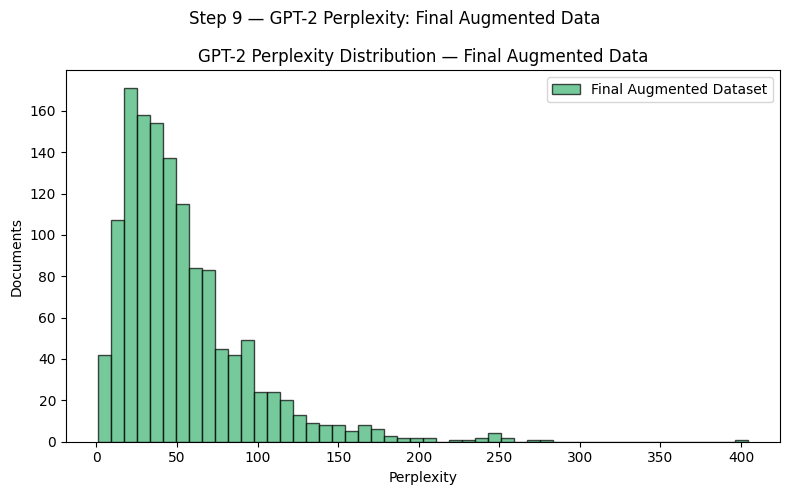

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

def compute_gpt2_perplexity(text, max_length=512):
    encodings = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    input_ids = encodings.input_ids.to(device)

    if input_ids.shape[1] < 2:
        return None

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

print(f"Computing GPT-2 perplexity on {len(final_training_dataset)} augmented documents...")

augmented_gpt2_perplexities = []
failed_augmented = 0

for i, doc in enumerate(final_training_dataset):
    ppl = compute_gpt2_perplexity(doc["raw_content"])
    if ppl is not None and ppl < 100000:
        augmented_gpt2_perplexities.append((i, ppl))
    else:
        failed_augmented += 1
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(final_training_dataset)}...")

a_valid_ppls = [ppl for _, ppl in augmented_gpt2_perplexities]
print(f"\nSuccessfully scored: {len(a_valid_ppls)} documents")

# Binned breakdown
bins = [0, 50, 100, 150, 200, 300, 500, 100000]
labels = ["Repetitive/Bot (<50)", "High Quality (50-100)", "Good Web (100-150)",
          "Informal (150-200)", "Noisy Web (200-300)", "Low Quality (300-500)", "High Perplexity (500+)"]

a_cats = pd.cut(pd.Series(a_valid_ppls), bins=bins, labels=labels).value_counts().sort_index()
print()
print(f"{'Category':<30} {'Count':>10}")
print("-" * 57)
for label in labels:
    a_count = a_cats.get(label, 0)
    print(f"  {label:<28} {a_count:>10}")

plt.figure(figsize=(8, 5))
plt.hist([p for p in a_valid_ppls if p < 1000], bins=50,
         color="mediumseagreen", edgecolor="black", alpha=0.7, label="Final Augmented Dataset")
plt.title("GPT-2 Perplexity Distribution — Final Augmented Data")
plt.xlabel("Perplexity")
plt.ylabel("Documents")
plt.legend()

plt.suptitle("Step 9 — GPT-2 Perplexity: Final Augmented Data")
plt.tight_layout()
plt.show()

# STEP 10 — Fine-tune GPT-2 on Preprocessed Data

Isti proces kao i sa originalnim skupom podataka kako bi se na kraju poredili generisani rezultati.

In [ ]:
import os, shutil, random, torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer, Trainer, TrainingArguments
from torch.utils.data import Dataset

# Updated to use the augmented dataset
output_dir = "./gpt2-final-augmented"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

random.seed(42)
# Use the final_training_dataset variable created in Step 8
sample_size = min(2000, len(final_training_dataset))
finetune_sample = random.sample(final_training_dataset, sample_size)
texts = [doc["raw_content"] for doc in finetune_sample]

print(f"Fine-tuning on {len(texts)} documents (Original + Augmented)")

with open("final_augmented_train.txt", "w", encoding="utf-8") as f:
    for text in texts:
        f.write(text.strip().replace("\n", " ") + "\n")

class TextFileDataset(Dataset):
    def __init__(self, file_path, tokenizer, block_size=128):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if len(line.strip()) > 10]
        self.examples = []
        for line in lines:
            enc = tokenizer(line, truncation=True, max_length=block_size,
                            padding="max_length", return_tensors="pt")
            self.examples.append(enc.input_ids.squeeze())
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        return {"input_ids": self.examples[idx], "labels": self.examples[idx]}

ft2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ft2_tokenizer.pad_token = ft2_tokenizer.eos_token
ft2_model = GPT2LMHeadModel.from_pretrained("gpt2")

train_dataset_final = TextFileDataset("final_augmented_train.txt", ft2_tokenizer, block_size=128)
print(f"Training examples: {len(train_dataset_final)}")

training_args = TrainingArguments(
    output_dir="./gpt2-final-augmented",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_steps=500,
    logging_steps=100,
    prediction_loss_only=True,
    report_to="none"
)

trainer2 = Trainer(
    model=ft2_model,
    args=training_args,
    train_dataset=train_dataset_final,
)

print("Starting fine-tuning on final augmented data...")
trainer2.train()
print("Fine-tuning complete.")

ft2_model.save_pretrained("./gpt2-final-augmented-final")
ft2_tokenizer.save_pretrained("./gpt2-final-augmented-final")
print("Model saved to ./gpt2-final-augmented-final")

Fine-tuning on 1334 documents (Original + Augmented)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training examples: 1334
Starting fine-tuning on final augmented data...


Step,Training Loss
100,1.938357
200,1.562065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./gpt2-final-augmented-final


### Greška je duplo manja nego kod originalnog modela i opada brže (veći korak pada greške u prvoj epohi). Ovo je dobar znak da je augmentirani skup podataka kvalitetniji i lakše se uči od originalnog  skupa podataka. Savršena vrednost gubitka za GPT-2 je između 1 i 1.8.

# STEP 11 — PROMPT TESTING


In [ ]:
from transformers import pipeline
import torch

# Load the model we just trained in Step 10
generator_augmented = pipeline(
    "text-generation",
    model="./gpt2-final-augmented-final",
    tokenizer="./gpt2-final-augmented-final",
    device=0 if torch.cuda.is_available() else -1
)

prompts = [
    "The researchers found that",
    "In recent years, artificial intelligence has",
    "The study concluded that data quality"
]

print("=" * 70)
print("STEP 11 — TEXT GENERATION WITH FINAL AUGMENTED GPT-2")
print("=" * 70)

for prompt in prompts:
    print(f"\nPROMPT: '{prompt}'")
    print("─" * 70)

    # Using max_new_tokens only to avoid conflicts with max_length
    outputs = generator_augmented(
        prompt,
        max_new_tokens=256,
        num_return_sequences=2,
        temperature=0.9,
        do_sample=True,
        pad_token_id=generator_augmented.tokenizer.eos_token_id,
        clean_up_tokenization_spaces=True
    )

    for i, output in enumerate(outputs):
        print(f"Generation {i+1}: {output['generated_text']}")
        print("-" * 30)
    print()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


STEP 11 — TEXT GENERATION WITH FINAL AUGMENTED GPT-2

PROMPT: 'The researchers found that'
──────────────────────────────────────────────────────────────────────


Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: The researchers found that women who had been sexually active for six months were more likely to report their initial relationship to an intimate partner.
------------------------------
Generation 2: The researchers found that adults showed most of the benefits of exercise — including better memory and lower anxiety — when they were older, and that exercise improved depression, anxiety, and eating disorders. Those groups also showed the strongest improvements in diet.
------------------------------


PROMPT: 'In recent years, artificial intelligence has'
──────────────────────────────────────────────────────────────────────


Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: In recent years, artificial intelligence has become more important than ever because it is being integrated more into the human experience of living and learning, as well as in the natural world as a whole.
------------------------------
Generation 2: In recent years, artificial intelligence has become a growing field in which we are working to capture insights that can help shape our daily lives, shape the way we build our businesses, and help us achieve greater things.
------------------------------


PROMPT: 'The study concluded that data quality'
──────────────────────────────────────────────────────────────────────
Generation 1: The study concluded that data quality in children in Romania can be improved by increasing the number of children being examined in the examination hall.
------------------------------
Generation 2: The study concluded that data quality is key to the success of a policy since the quality of the administration can be influenced by the influenc

Nema ponavljanja rečenica, halucinacija u vidu citata, rečenice su čitljive i koherentne, logičnije nego kod prethodnog modela. Pominjanje Rumunije može delovati kao da se model specijalizovao za određene teme iz specifičnih dokumenata u skupu podataka.
